In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [3]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [5]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

In [6]:
print("X : ", X.shape)
print("Y : ", y.shape)

X :  (569, 30)
Y :  (569,)


In [7]:
print(X.isnull().sum().sum())

0


In [8]:
X.duplicated().sum()

np.int64(0)

In [9]:
y.unique()

array([0, 1])

In [13]:
print(y.value_counts(normalize=True) * 100)

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


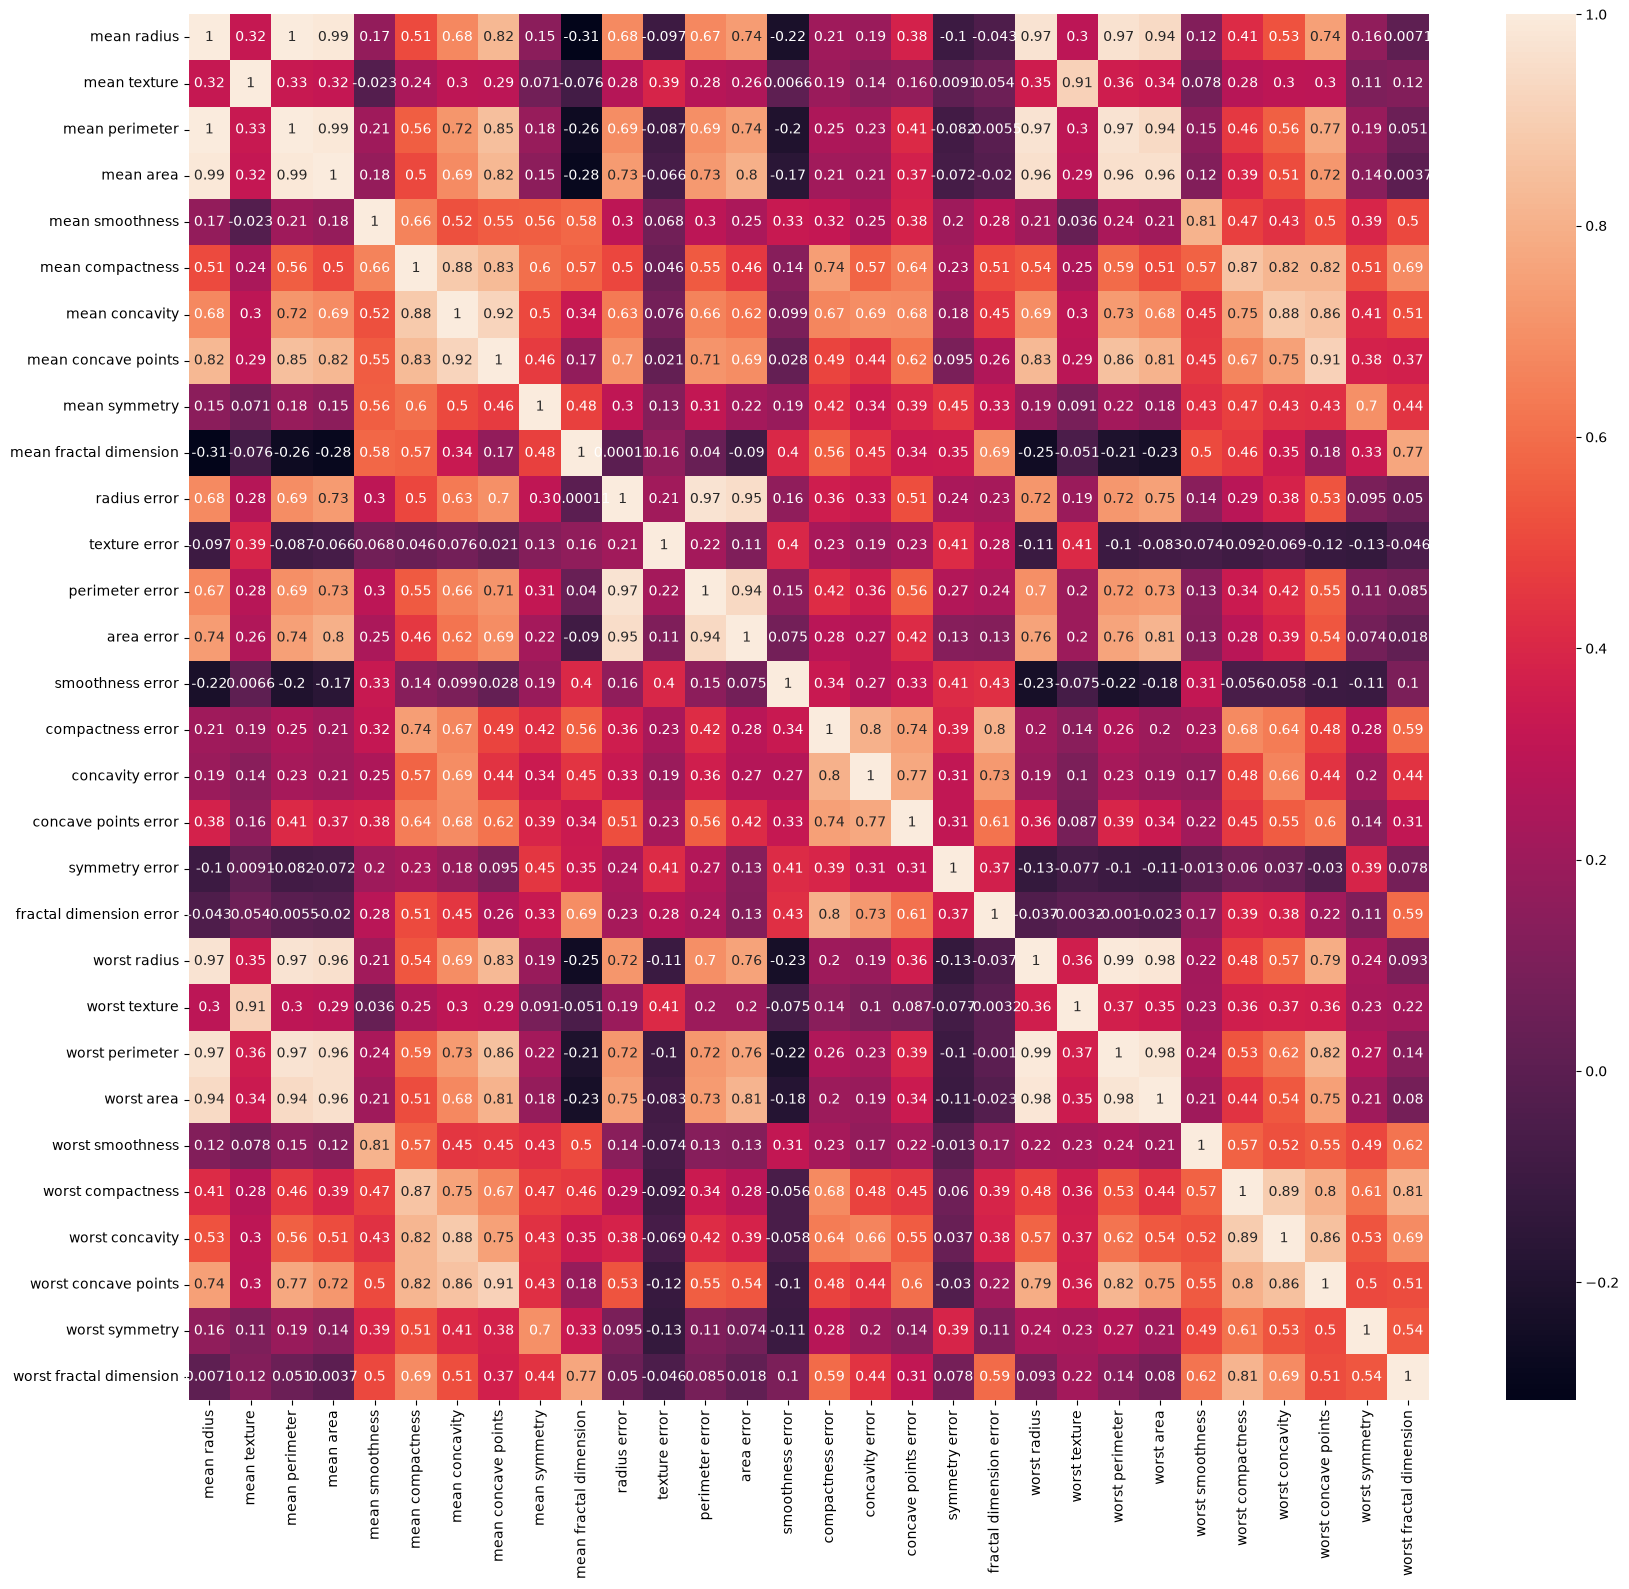

In [17]:
corr = X.corr()
plt.figure(figsize=(20,18))
sns.heatmap(corr, annot=True)
plt.show()

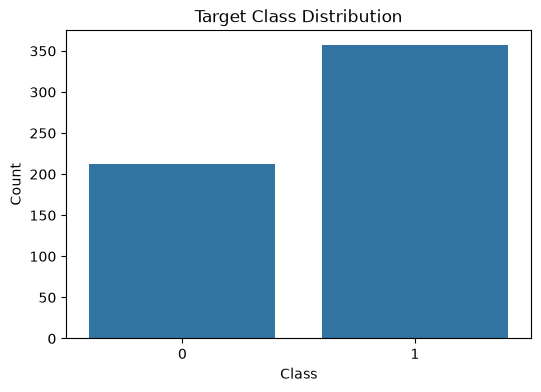

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
cnm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1Score = f1_score(y_test, y_pred)


print("Confusion Matrix : \n", cnm, "\n")

print("Accuracy : ", accuracy)
print("Precision : ", precision)
print("Recall : ", recall)
print("F1 Score : ", f1Score)

Confusion Matrix : 
 [[38  4]
 [ 3 69]] 

Accuracy :  0.9385964912280702
Precision :  0.9452054794520548
Recall :  0.9583333333333334
F1 Score :  0.9517241379310345


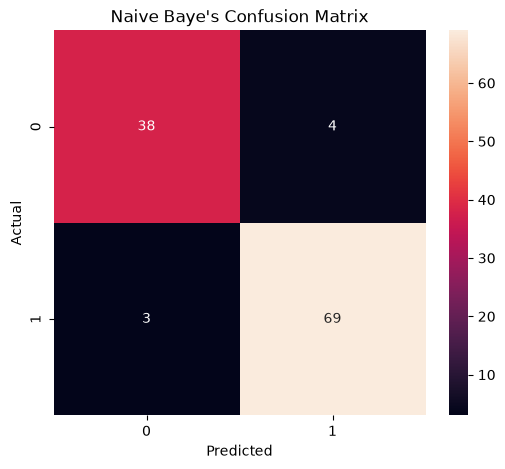

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cnm,
    annot=True,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Baye's Confusion Matrix")
plt.show()

In [27]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [28]:
result = pd.DataFrame({
    "Actual" : y_test.values,
    "Predicted" : y_pred
})
print(result.head(10))

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       0          0
5       1          1
6       1          1
7       0          0
8       0          0
9       0          0


In [30]:
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(cv_scores)
print(cv_scores.mean())

[0.93406593 0.94505495 0.93406593 0.93406593 0.93406593]
0.9362637362637363


In [31]:
param_grid = {
    "var_smoothing" : [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5,
        1e-4,
        1e-3,
    ]
}

grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-11, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy us

In [32]:
print("Best Params : ", grid_search.best_params_)
print("Best CV Accuracy : ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Best Model : ", best_model)

Best Params :  {'var_smoothing': 1e-09}
Best CV Accuracy :  0.9362637362637363
Best Model :  GaussianNB()


In [34]:
y_pred_best = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Accuracy : ", accuracy)
print("Precision : ", precision)
print("Recall : ", recall)
print("F1 Score : ", f1)

Accuracy :  0.9385964912280702
Precision :  0.9452054794520548
Recall :  0.9583333333333334
F1 Score :  0.9517241379310345
